In [5]:
import numpy as np

N = 10**5

rng = np.random.default_rng(2026)

U = rng.random(N)

z = 1 - np.sqrt(1 - U)

# Sample mean
sample_mean = np.mean(z)

print("======================================")
print("Part (b)")
print("======================================")
print("Number of samples =", N)
print("Sample mean =", sample_mean)
print("Theoretical mean =", 1/3)

Part (b)
Number of samples = 100000
Sample mean = 0.3320173845050077
Theoretical mean = 0.3333333333333333


Problem 5
Number of realizations = 1000
Final N = 10000
Empirical mean = 0.33050070000000004
Empirical standard deviation = 0.23800730259702116
Empirical SD/mean ratio = 0.7201415990859358
Smallest core = 3
Largest core = 9549


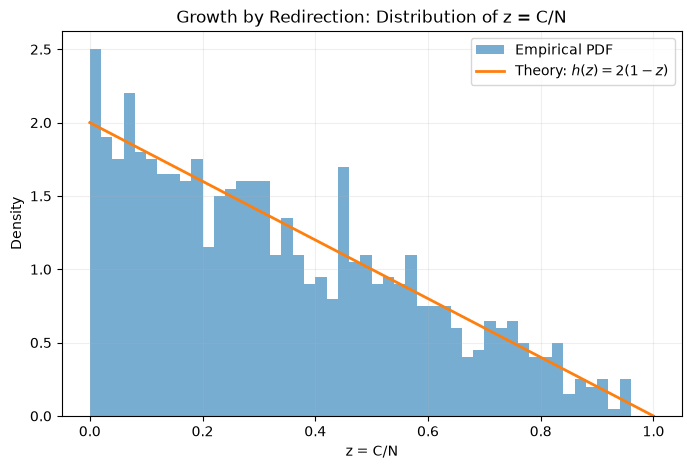

In [6]:
import matplotlib.pyplot as plt
import os

N = 10**4
R = 10**3

rng = np.random.default_rng(2026)



# Simulate the growth process

# C(3) = 1 for all R realizations
C = np.ones(R, dtype=int)

for n in range(3, N):

    p = C / n

    # One Bernoulli draw for all R realizations
    B = rng.random(R) < p

    C += B


# Final value of z = C/N
z = C / N



# Empirical results

empirical_mean = np.mean(z)

empirical_sd = np.std(z)

empirical_ratio = empirical_sd / empirical_mean

smallest_core = np.min(C)

largest_core = np.max(C)


print("======================================")
print("Problem 5")
print("======================================")

print("Number of realizations =", R)
print("Final N =", N)

print("Empirical mean =", empirical_mean)

print("Empirical standard deviation =", empirical_sd)

print("Empirical SD/mean ratio =", empirical_ratio)

print("Smallest core =", smallest_core)

print("Largest core =", largest_core)


# Plot

bin_width = 0.02

bins = np.arange(
    0,
    1 + bin_width,
    bin_width
)

plt.figure(figsize=(8, 5))

plt.hist(
    z,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Empirical PDF"
)



x = np.linspace(0, 1, 1000)

h = 2 * (1 - x)

plt.plot(
    x,
    h,
    linewidth=2,
    label=r"Theory: $h(z)=2(1-z)$"
)


plt.xlabel("z = C/N")
plt.ylabel("Density")

plt.title("Growth by Redirection: Distribution of z = C/N")

plt.legend()

plt.grid(alpha=0.2)

plt.savefig(
    os.path.expanduser("~/Downloads/problem5_plot.pdf"),
    bbox_inches="tight"
)

plt.show()